In [1]:
import sys

sys.path.insert(0, "..")

from configparser import ConfigParser

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from src.core.models.gp_kan.dense_layer import (
    DenseGPLayer,
)
from src.core.models.gp_kan.gp_kan import GP_KAN
from src.core.models.gp_kan.normal_dist import NormalDist

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)


def make_kan_config(**overrides):
    cfg = ConfigParser()
    defaults = {
        "NETWORK": {"input_size": "1", "output_size": "1"},
        "GP": {
            "num_inducing_points": "6",
            "z_init_low": "-2",
            "z_init_high": "2",
            "h_init_low": "-1",
            "h_init_high": "1",
            "global_length_scale": "0.4",
            "min_length_scale": "0.2",
            "global_covariance_scale": "1.0",
            "min_covariance_scale": "0.1",
            "global_jitter": "1e-3",
            "baseline_jitter": "1e-2",
        },
        "NORMALIZATION": {"min_var": "0.2"},
        "TRAINING": {
            "seed": "42",
            "learning_rate": "0.001",
            "num_epochs": "30",
            "batch_size": "32",
            "pretrain_iters": "10",
        },
        "DEVICE": {"use_gpu": "false", "device": "cpu", "precision": "float32"},
    }
    for section, vals in defaults.items():
        cfg[section] = vals
    for section, vals in overrides.items():
        if section not in cfg:
            cfg[section] = {}
        cfg[section].update(vals)
    return cfg

# GP-KAN: Gaussian Process Kolmogorov-Arnold Networks

Standard neural networks use fixed activation functions (ReLU, tanh, ...) and learn the weights. A **Kolmogorov-Arnold Network (KAN)** [(Liu, 2024)](https://arxiv.org/abs/2404.19756) instead places learnable univariate functions on the edges and sums at the nodes. 

In vanilla KAN, $\phi_{q,p}$ are parameterised as splines. **GP-KAN** [(Chen, 2024)](https://arxiv.org/abs/2407.18397) replaces them with **Gaussian processes**, which gives:

1. **Uncertainty quantification**: each GP neuron outputs a distribution, not a point estimate
2. **Analytical propagation**: if the input is Gaussian and the neuron is a GP, the output is (approximately) Gaussian, so uncertainty flows through the entire network without sampling

### Code

| Component | What it does |
|-----------|-------------|
| `DenseGPLayer` | Fully-connected layer of GP neurons. Maps $\mathcal{N}^I \to \mathcal{N}^O$ with analytical mean/variance. |
| `NormaliseGaussian` | Activation that keeps the distribution approximately Gaussian between layers. |
| `NormalDist` | Data structure carrying mean and variance vectors through the network. |
| `GP_KAN` | Stacks layers + activations. Handles pretraining (L-BFGS) and main training (SGD). |

### Forward pass

1. Wrap input $\mathbf{x}$ as $\mathcal{N}(\mathbf{x}, \sigma_{\text{in}}^2 I)$ with learned input noise
2. For each layer:
   - Build kernel matrices $K_{zz}$ (inducing-inducing) and $\mathbf{q}_{xz}$ (query-inducing, with input variance)
   - Cholesky decompose $K_{zz} + \text{noise} \cdot I = LL^\top$
   - Compute output mean: $\boldsymbol{\mu}_y = \sum_i \mathbf{q}_{xz_i} K_{zz_i}^{-1} \mathbf{h}_i$
   - Compute output variance: prior term $-$ inducing reduction $+$ jitter
   - Apply activation (if not final layer)
3. Output: $\mathcal{N}(\boldsymbol{\mu}_y, \text{diag}(\boldsymbol{\sigma}_y^2))$

## The GP neuron

A standard sigmoidal-activation neuron outputs $y = \sigma(w^\top x + b)$: a dot product, then a nonlinearity. A **GP neuron** replaces this with an inner product between a function sample and the input distribution:

$$y = \langle f,\, p(x) \rangle = \int f(x)\, p(x)\, dx$$

where $f \sim \mathcal{GP}(m(\cdot),\, k(\cdot, \cdot) \mid \mathbf{h}, \mathbf{z})$ is a GP conditioned on inducing points $(\mathbf{z}, \mathbf{h})$, and $p(x) = \mathcal{N}(x \mid \mu_x, \sigma_x^2)$ is the input distribution.

Each GP neuron has parameters:

| Parameter | Shape | Transform | Role |
|-----------|-------|-----------|------|
| $\mathbf{z}$ | $(I, O, P)$ | $\tanh$ | Inducing point locations |
| $\mathbf{h}$ | $(I, O, P)$ | none | Function values at inducing points |
| $\ell$ | $(I, O)$ | $\exp + \ell_{\min}$ | Length scale |
| $s$ | $(I, O)$ | $\exp + s_{\min}$ | Signal variance |
| $\delta$ | $(I, O)$ | $\exp + \delta_0$ | Jitter (noise regularisation) |

where $I$ is input size, $O$ is output size, $P$ is the number of inducing points per neuron. The transforms ensure positivity for the hyperparameters and boundedness for inducing locations.

### Kernel choice

The kernel is the **normalised squared exponential** (the gaussian RBF kernel, except normalised to PDF):

$$k(x, x') = \mathcal{N}(x \mid x',\, \ell^2) = \frac{1}{\sqrt{2\pi\ell^2}} \exp\!\left(-\frac{(x - x')^2}{2\ell^2}\right)$$

Using the normal PDF rather than the standard RBF makes the inner product $\langle f, p(x) \rangle$ analytically tractable when $p(x)$ is also Gaussian, since the product of two Gaussians is Gaussian, (up to a normalising constant). The integral then has a closed form.

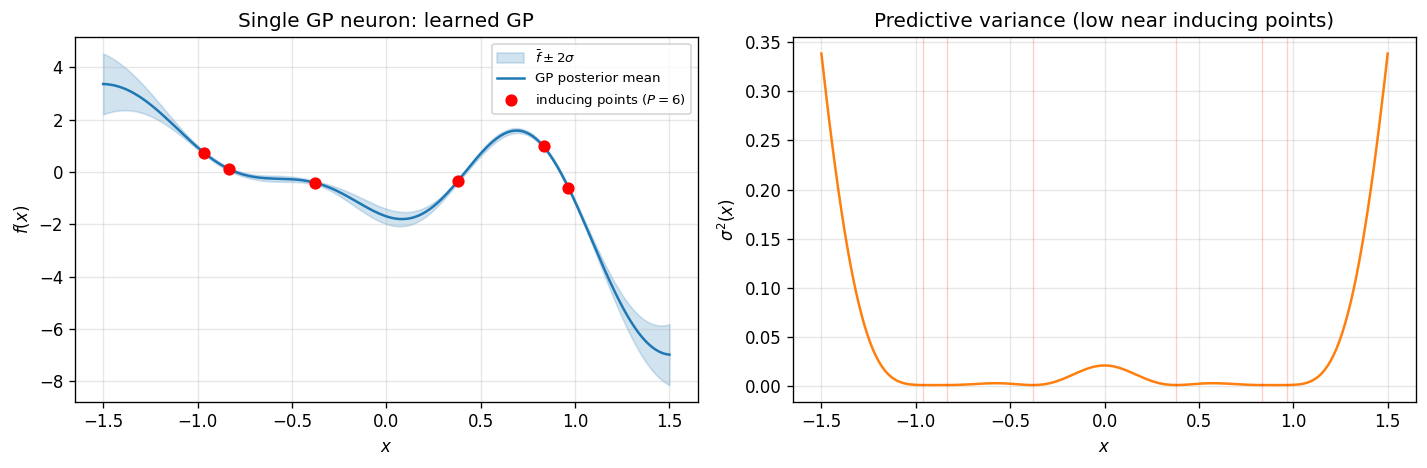

In [2]:
np.random.seed(42)
cfg = make_kan_config(GP={"num_inducing_points": "6"})
layer = DenseGPLayer(
    input_size=1, output_size=1, config=cfg, key=jax.random.PRNGKey(7)
)  # Single neuron

x_grid = jnp.linspace(-1.5, 1.5, 200).reshape(-1, 1)
tiny_var = 1e-8 * jnp.ones_like(
    x_grid
)  # Near-zero input variance -> deterministic query
out = layer.forward(NormalDist(x_grid, tiny_var))

z = np.asarray(layer.get_z()[0, 0, :])  # Inducing points for neuron (0,0)
h = np.asarray(layer.h[0, 0, :])  # Function vals at inducing points
mu = np.asarray(out.mean[:, 0])
std = np.sqrt(np.maximum(np.asarray(out.var[:, 0]), 0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.fill_between(
    x_grid.ravel(),
    mu - 2 * std,
    mu + 2 * std,
    alpha=0.2,
    color="C0",
    label=r"$\bar{f} \pm 2\sigma$",
)
ax.plot(x_grid, mu, "C0", lw=1.5, label="GP posterior mean")
ax.scatter(z, h, c="red", s=40, zorder=5, label=f"inducing points ($P={len(z)}$)")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Single GP neuron: learned GP")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x_grid, std**2, "C1", lw=1.5)
for zi in z:
    ax.axvline(zi, color="red", alpha=0.2, lw=0.8)
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\sigma^2(x)$")
ax.set_title("Predictive variance (low near inducing points)")

plt.tight_layout()
plt.show()

## Analytical uncertainty propagation

If input is $x \sim \mathcal{N}(\mu_x, \sigma_x^2)$ and the neuron's function is $f \sim \mathcal{GP}(\cdot \mid \mathbf{h}, \mathbf{z})$, the output $y = \langle f, p(x) \rangle$ has closed-form mean and variance, (see original paper for derivations).

### Query-inducing kernel

The inner product $\langle k(\cdot, z_j),\, p(x) \rangle$ between the kernel section at inducing point $z_j$ and the input distribution $p(x) = \mathcal{N}(x \mid \mu_x, \sigma_x^2)$ is:

$$q(\mu_x, z_j) = \int \mathcal{N}(t \mid z_j, \ell^2) \, \mathcal{N}(t \mid \mu_x, \sigma_x^2) \, dt = \mathcal{N}(\mu_x \mid z_j,\, \ell^2 + \sigma_x^2)$$

This is convolution of two Gaussians: the kernel at $z_j$ and the input dist. Input uncertainty $\sigma_x^2$ adds to the kernel's length scale $\ell^2$, (effectively regularising the query).

### Out mean

Standard GP prediction conditioned on inducing points:

$$\mathbb{E}[y] = \mathbf{q}_{xz}\, K_{zz}^{-1}\, \mathbf{h}$$

where $\mathbf{q}_{xz}$ is the vector of query-inducing kernel values (with input variance folded in), $K_{zz}$ is the inducing-inducing kernel matrix, and $\mathbf{h}$ are the function values at the inducing points.

### Out variance

$$\text{Var}[y] = \underbrace{s^2 \frac{|\ell|}{\sqrt{\ell^2 + 2\sigma_x^2}}}_{\text{prior variance}} - \underbrace{\sqrt{2\pi}\, s^2 |\ell| \cdot \mathbf{q}_{xz} K_{zz}^{-1} \mathbf{q}_{zx}}_{\text{uncertainty reduction}} + \delta_0$$

The first term is prior variance of the inner product (depends on input uncertainty, more uncertain input -> more uncertain output). The second term subtracts variance explained by the inducing points. The residual $\delta_0$ is a jitter floor.

### Cholesky solve

Instead of forming and inverting, $K_{zz}^{-1}$, use Cholesky decomposed form, $K_{zz} + \text{noise} \cdot I = LL^\top$:

- Mean: $\mathbf{q}_{xz} (L^{-\top} L^{-1}) \mathbf{h}$
- Variance reduction: $\|\mathbf{q}_{xz} L^{-\top}\|^2 = \mathbf{q}_{xz} K_{zz}^{-1} \mathbf{q}_{zx}$

This is $\mathcal{O}(P^3)$ per neuron, but $P$ is small (typically 4--10).

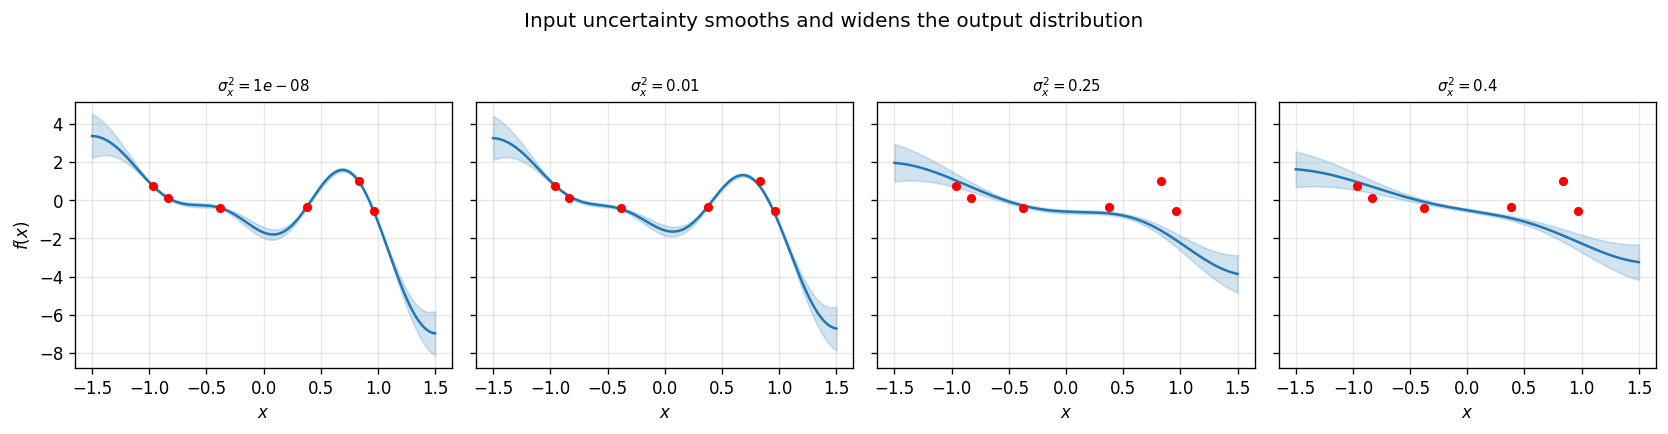

In [3]:
input_variances = [1e-8, 0.01, 0.25, 0.4]
x_grid = jnp.linspace(-1.5, 1.5, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, len(input_variances), figsize=(14, 3.5), sharey=True)
for ax, in_var in zip(axes, input_variances):
    var_arr = in_var * jnp.ones_like(x_grid)
    out = layer.forward(NormalDist(x_grid, var_arr))
    mu = np.asarray(out.mean[:, 0])
    std = np.sqrt(np.maximum(np.asarray(out.var[:, 0]), 0))

    ax.fill_between(x_grid.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="C0")
    ax.plot(x_grid, mu, "C0", lw=1.5)
    ax.scatter(z, h, c="red", s=20, zorder=5)
    ax.set_title(rf"$\sigma_x^2 = {in_var}$", fontsize=9)
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$f(x)$")
plt.suptitle("Input uncertainty smooths and widens the output distribution", y=1.02)
plt.tight_layout()
plt.show()

## Fully-connected GP layer

A single layer maps $\mathcal{N}(\boldsymbol{\mu}_x, \text{diag}(\boldsymbol{\sigma}_x^2)) \in \mathbb{R}^I$ to $\mathcal{N}(\boldsymbol{\mu}_y, \text{diag}(\boldsymbol{\sigma}_y^2)) \in \mathbb{R}^O$.

For each output neuron $j$, there are $I$ GP neurons (one per input), and the output is **sum of independent Gaussian random variables**:

$$y_j = \sum_{i=1}^{I} \langle f_{ij},\, p(x_i) \rangle$$

Since each inner product gives a Gaussian and they are independent, (conditioned on the GPs), the sum is Gaussian with:

$$\mu_{y_j} = \sum_{i=1}^{I} \mu_{ij}, \qquad \sigma_{y_j}^2 = \sum_{i=1}^{I} \sigma_{ij}^2$$

This done by `DenseGPLayer.forward()`. Total parameters per layer: $I \times O \times (2P + 3)$ (inducing locations, values, length scale, signal variance, jitter).

### Gaussian-preserving activations

Between layers, the distribution must remain (approximately) Gaussian. The activation `NormaliseGaussian` applies:

$$\mu_{\text{out}} = \tanh(\mu_{\text{in}}), \qquad \sigma_{\text{out}}^2 = \text{sigmoid}(\sigma_{\text{in}}^2 - \mu_{\text{in}}^2 + c)$$

where $c = \text{sigmoid}^{-1}(\sigma_{\min}^2)$ ensures a variance floor. The tanh bounds the mean to $(-1, 1)$; the sigmoid bounds the variance to $(\sigma_{\min}^2, 1)$. The argument $\sigma^2 - \mu^2$ is the second central moment minus the squared mean, which calibrates how much variance passes through.

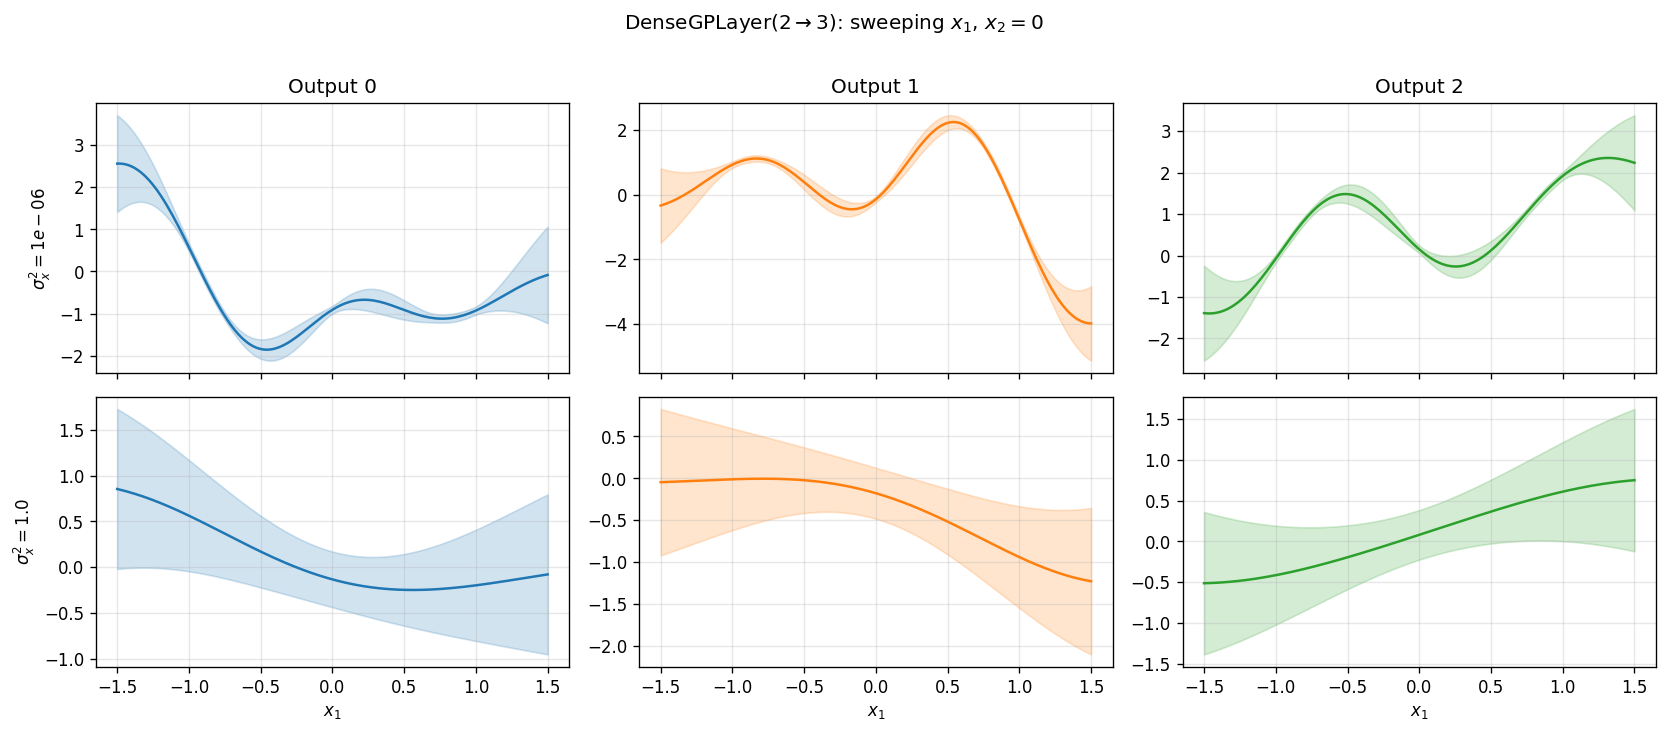

Parameters per neuron: 2*P + 3 = 13
Total layer parameters: I*O*(2P+3) = 78


In [4]:
cfg2 = make_kan_config(
    NETWORK={"input_size": "2", "output_size": "3"},
    GP={"num_inducing_points": "5"},
)
layer2 = DenseGPLayer(
    input_size=2,
    output_size=3,
    config=cfg2,
    key=jax.random.PRNGKey(0),  # Full layer
)

# Sweep x1 while holding x2 = 0, at two different input uncertainties
x1_vals = jnp.linspace(-1.5, 1.5, 150)

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for row, in_var in enumerate([1e-6, 1.0]):
    means_list, vars_list = [], []
    for x1 in x1_vals:
        inp = NormalDist(
            jnp.array([[float(x1), 0.0]]),
            jnp.array([[in_var, in_var]]),
        )
        out = layer2.forward(inp)
        means_list.append(np.asarray(out.mean[0]))
        vars_list.append(np.asarray(out.var[0]))
    means = np.array(means_list)
    varis = np.array(vars_list)

    for j in range(3):
        ax = axes[row, j]
        mu, std = means[:, j], np.sqrt(np.maximum(varis[:, j], 0))
        ax.fill_between(x1_vals, mu - 2 * std, mu + 2 * std, alpha=0.2, color=f"C{j}")
        ax.plot(x1_vals, mu, f"C{j}", lw=1.5)
        if row == 0:
            ax.set_title(f"Output {j}")
        if j == 0:
            ax.set_ylabel(rf"$\sigma_x^2 = {in_var}$")
        if row == 1:
            ax.set_xlabel("$x_1$")

plt.suptitle(r"DenseGPLayer($2 \to 3$): sweeping $x_1$, $x_2 = 0$", y=1.01)
plt.tight_layout()
plt.show()
print(f"Parameters per neuron: 2*P + 3 = {2 * 5 + 3}")
print(f"Total layer parameters: I*O*(2P+3) = {2 * 3 * (2 * 5 + 3)}")

## Network architecture

A FC GP-KAN stacks `DenseGPLayer`s with `NormaliseGaussian` activations between them:

$$\mathbf{x}^{(0)} \xrightarrow{\text{GP layer}} \mathbf{x}^{(1)} \xrightarrow{\text{normalise}} \hat{\mathbf{x}}^{(1)} \xrightarrow{\text{GP layer}} \cdots \xrightarrow{\text{GP layer}} \mathbf{y}$$

At each stage, the data is a `NormalDist` (mean vector + variance vector). Deterministic inputs enter with a learned input noise $\sigma_{\text{in}}^2 = \exp(\theta_{\text{noise}})^2$ to seed the uncertainty.

### Training

**Loss**: -ve Gaussian log-likelihood of the targets under predicted dist:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \mathcal{N}(y_i \mid \mu_i, \sigma_i^2) = \frac{1}{N} \sum_{i=1}^{N} \left[ \frac{1}{2} \log(2\pi\sigma_i^2) + \frac{(y_i - \mu_i)^2}{2\sigma_i^2} \right]$$

This jointly optimises accuracy ($\mu_i \approx y_i$) and calibration ($\sigma_i^2$ should be neither too large nor too small). Unlike MSE, being overconfident (small $\sigma_i^2$, wrong $\mu_i$) is heavily penalised.

**Pretraining**: before main loop, the inducing point log-likelihood

$$\log p(\mathbf{h} \mid \mathbf{z}, \ell, s) = -\tfrac{1}{2} \mathbf{h}^\top K_{zz}^{-1} \mathbf{h} - \log|L| - \tfrac{P}{2}\log(2\pi)$$

is maximised with **L-BFGS** to initialise the kernel hyperparameters $(\ell, s, \delta)$ so that the GP prior is consistent with the inducing point values. This is a second-order optimiser.

**Main training**: SGD with momentum 0.9 and gradient clipping on all params.

GP_KAN(1→4 → 4→1, GPU=False)
Layers: 2, Activations: ['NormaliseGaussian', None]


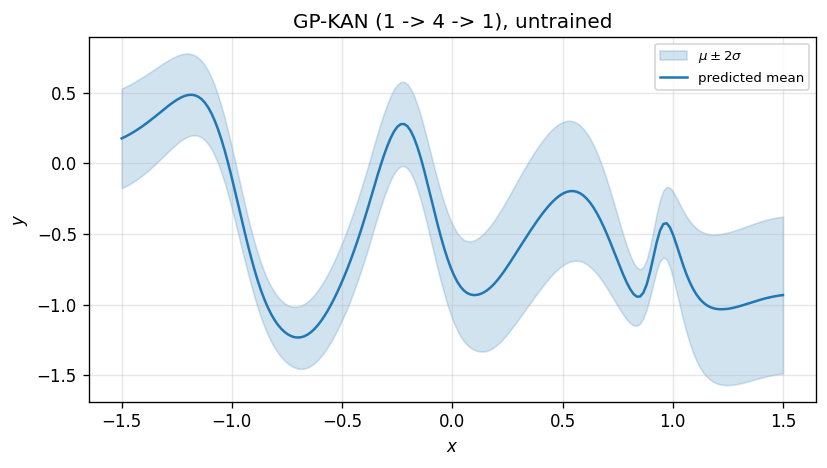

In [5]:
cfg_net = make_kan_config(
    NETWORK={"input_size": "1", "output_size": "1"},
    GP={"num_inducing_points": "5"},
)
net = GP_KAN(
    cfg_net,
    hidden_sizes=[4],
    activation_types=["NormaliseGaussian"],
)
print(net)
print(
    f"Layers: {len(net.layers)}, Activations: {[type(a).__name__ if a else None for a in net.activations]}"
)

# Forward pass on a grid (untrained)
x_grid = jnp.linspace(-1.5, 1.5, 200).reshape(-1, 1)
out_untrained = net.predict(x_grid)
mu_u = np.asarray(out_untrained.mean[:, 0])
std_u = np.sqrt(np.maximum(np.asarray(out_untrained.var[:, 0]), 0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(
    x_grid.ravel(),
    mu_u - 2 * std_u,
    mu_u + 2 * std_u,
    alpha=0.2,
    color="C0",
    label=r"$\mu \pm 2\sigma$",
)
ax.plot(x_grid, mu_u, "C0", lw=1.5, label="predicted mean")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("GP-KAN (1 -> 4 -> 1), untrained")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Example

Below: train a GP-KAN on $f(x) = \sin(2x) + 0.3\cos(5x)$ with Gaussian noise $\varepsilon \sim \mathcal{N}(0, 0.04)$. The network learns both the function shape and appropriate uncertainty bands.

In [6]:
np.random.seed(42)
f_true = lambda x: np.sin(2 * x) + 0.3 * np.cos(5 * x)
noise_std = 0.2
X_train = np.sort(np.random.uniform(-3, 3, 60)).reshape(-1, 1)
y_train = f_true(X_train.ravel()) + noise_std * np.random.randn(len(X_train))
X_test = np.linspace(-4, 4, 300).reshape(-1, 1)

cfg_train = make_kan_config(
    NETWORK={"input_size": "1", "output_size": "1"},
    GP={
        "num_inducing_points": "8",
        "z_init_low": "-2",
        "z_init_high": "2",
        "h_init_low": "-0.5",
        "h_init_high": "0.5",
        "global_length_scale": "0.4",
        "min_length_scale": "0.1",
        "global_covariance_scale": "0.5",
        "min_covariance_scale": "0.1",
        "global_jitter": "0.01",
        "baseline_jitter": "0.01",
    },
    TRAINING={
        "seed": "42",
        "learning_rate": "0.005",
        "num_epochs": "80",
        "batch_size": "20",
        "pretrain_iters": "20",
    },
)

net_train = GP_KAN(
    cfg_train,
    hidden_sizes=[8],
    activation_types=["NormaliseGaussian"],
)

net_train.train(
    X_train,
    y_train,
    num_epochs=80,
    batch_size=20,
    patience=50,
    pretrain_iters=20,
)

Pretraining GP hyperparameters...
  Pretrain 0: Inducing point log-likelihood -193.2168
  Pretrain 5: Inducing point log-likelihood 4.3079
  Pretrain 10: Inducing point log-likelihood 15.3348
  Pretrain 15: Inducing point log-likelihood 27.5292
Epoch 0: Train Loss = 2.5076
Epoch 5: Train Loss = 1.9960
Epoch 10: Train Loss = 1.2481
Epoch 15: Train Loss = 0.9367
Epoch 20: Train Loss = 0.8405
Epoch 25: Train Loss = 0.7116
Epoch 30: Train Loss = 0.5751
Epoch 35: Train Loss = 0.5017
Epoch 40: Train Loss = 0.8465
Epoch 45: Train Loss = 0.6432
Epoch 50: Train Loss = 0.4711
Epoch 55: Train Loss = 0.3416
Epoch 60: Train Loss = 0.2572
Epoch 65: Train Loss = 0.2156
Epoch 70: Train Loss = 0.2090
Epoch 75: Train Loss = 0.1452


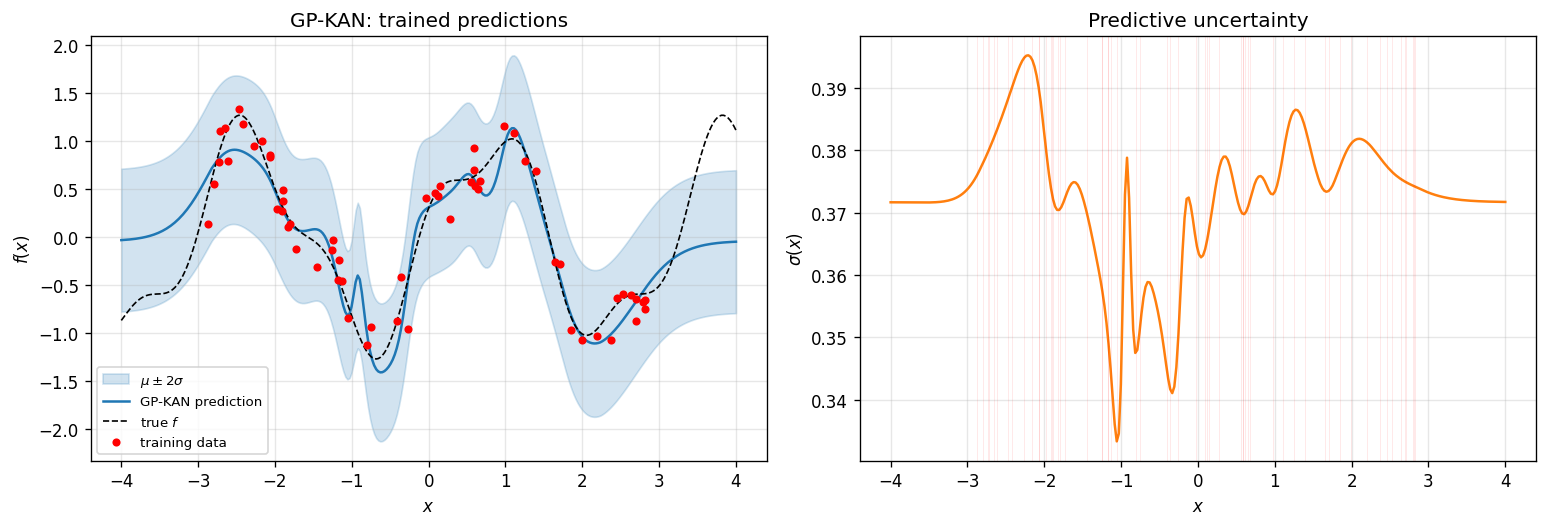

In [7]:
out_trained = net_train.predict(jnp.array(X_test))
mu_t = np.asarray(out_trained.mean[:, 0])
std_t = np.sqrt(np.maximum(np.asarray(out_trained.var[:, 0]), 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.fill_between(
    X_test.ravel(),
    mu_t - 2 * std_t,
    mu_t + 2 * std_t,
    alpha=0.2,
    color="C0",
    label=r"$\mu \pm 2\sigma$",
)
ax.plot(X_test, mu_t, "C0", lw=1.5, label="GP-KAN prediction")
ax.plot(X_test, f_true(X_test.ravel()), "k--", lw=1, label="true $f$")
ax.scatter(X_train, y_train, c="red", s=15, zorder=5, label="training data")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("GP-KAN: trained predictions")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(X_test, std_t, "C1", lw=1.5)
for xi in X_train.ravel():
    ax.axvline(xi, color="red", alpha=0.1, lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\sigma(x)$")
ax.set_title("Predictive uncertainty")

plt.tight_layout()
plt.show()

## Inside the GP neuron

After training, each GP neuron has learned a *different univariate function*. 

Below: the learned functions in the first layer of the trained network are plotted. Each neuron transforms one input dimension into one contribution to each hidden unit.

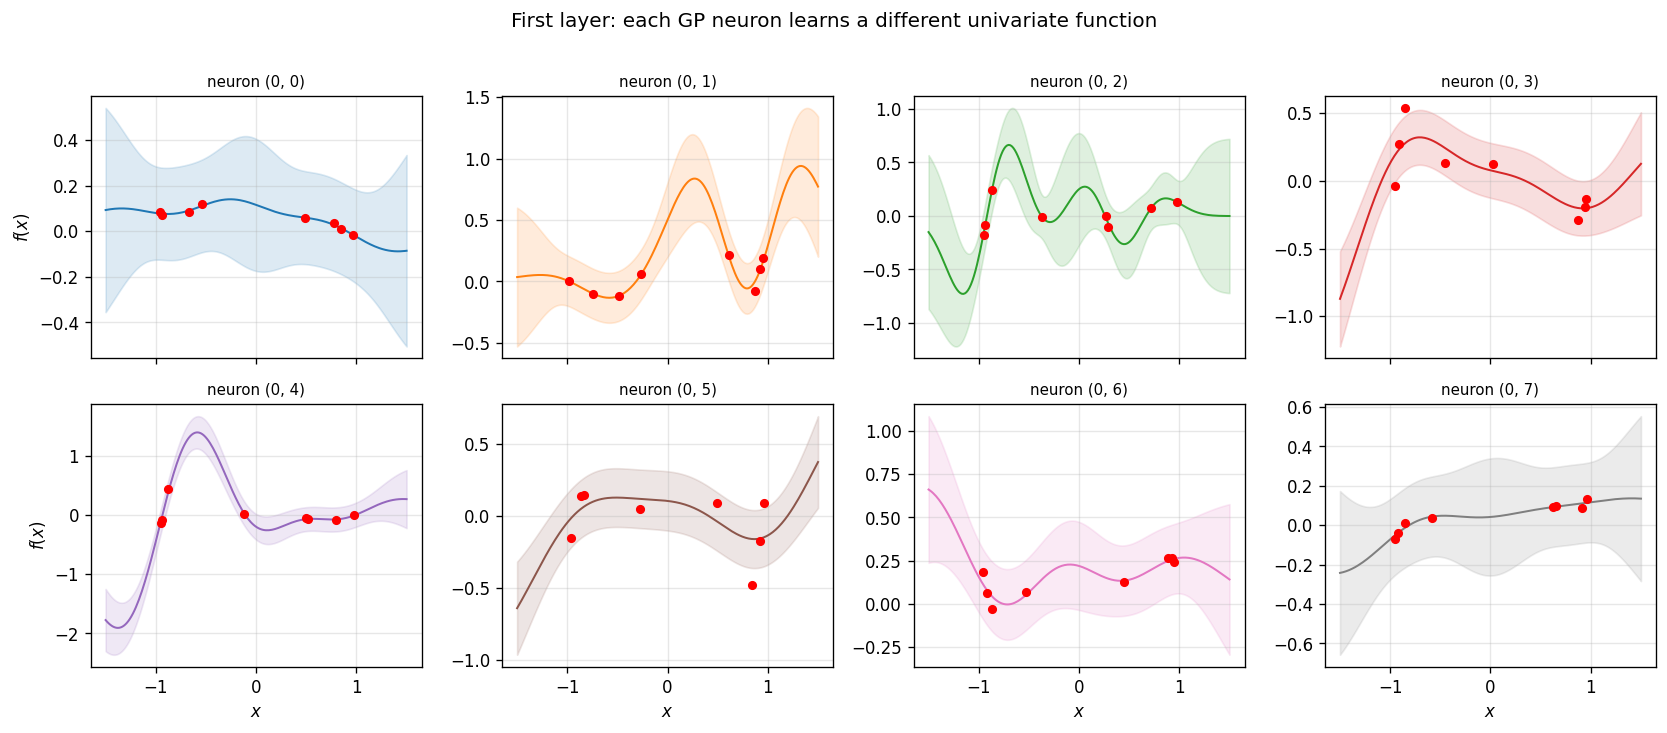

In [8]:
first_layer = net_train.layers[0]
x_grid = jnp.linspace(-1.5, 1.5, 200).reshape(-1, 1)
tiny_var = 1e-8 * jnp.ones_like(x_grid)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True)
for j in range(first_layer.output_dim):
    ax = axes[j // 4, j % 4]

    # Extract neuron output by masking
    out = first_layer.forward(NormalDist(x_grid, tiny_var))
    z_j = np.asarray(first_layer.get_z()[0, j, :])
    h_j = np.asarray(first_layer.h[0, j, :])

    # For a 1->O layer, each output j is a single GP neuron for I=1
    mu_j = np.asarray(out.mean[:, j])
    std_j = np.sqrt(np.maximum(np.asarray(out.var[:, j]), 0))

    ax.fill_between(
        x_grid.ravel(), mu_j - 2 * std_j, mu_j + 2 * std_j, alpha=0.15, color=f"C{j}"
    )
    ax.plot(x_grid, mu_j, f"C{j}", lw=1.2)
    ax.scatter(z_j, h_j, c="red", s=20, zorder=5)
    ax.set_title(f"neuron (0, {j})", fontsize=9)
    if j % 4 == 0:
        ax.set_ylabel("$f(x)$")
    if j >= 4:
        ax.set_xlabel("$x$")

plt.suptitle(
    "First layer: each GP neuron learns a different univariate function", y=1.01
)
plt.tight_layout()
plt.show()

## GP-KAN vs GP

| | Standard GP | GP-KAN |
|--|------------|--------|
| Model | Single GP over all inputs | Network of GP neurons |
| Kernel | One global kernel | Per-neuron kernels with learned hyperparameters |
| Expressiveness | Limited by kernel choice | Compositional: inner functions + sums |
| Cost | $\mathcal{O}(n^3)$ in data | $\mathcal{O}(LP^3)$ in inducing points ($L$ = layers) |
| Uncertainty | Exact posterior | Approximate (Gaussian closure at each layer) |
| Scaling | Needs sparse approx. for $n > 2000$ | Cost independent of $n$ (only depends on architecture) |

GP-KAN's uncertainty is approximate, (the output of a GP neuron isn't exactly Gaussian, just close), but the architecture scales to high-dimensional inputs where a single GP would need a huge kernel matrix. The cost is $\mathcal{O}(LP^3 \cdot I \cdot O)$ per forward pass, independent of dataset size.

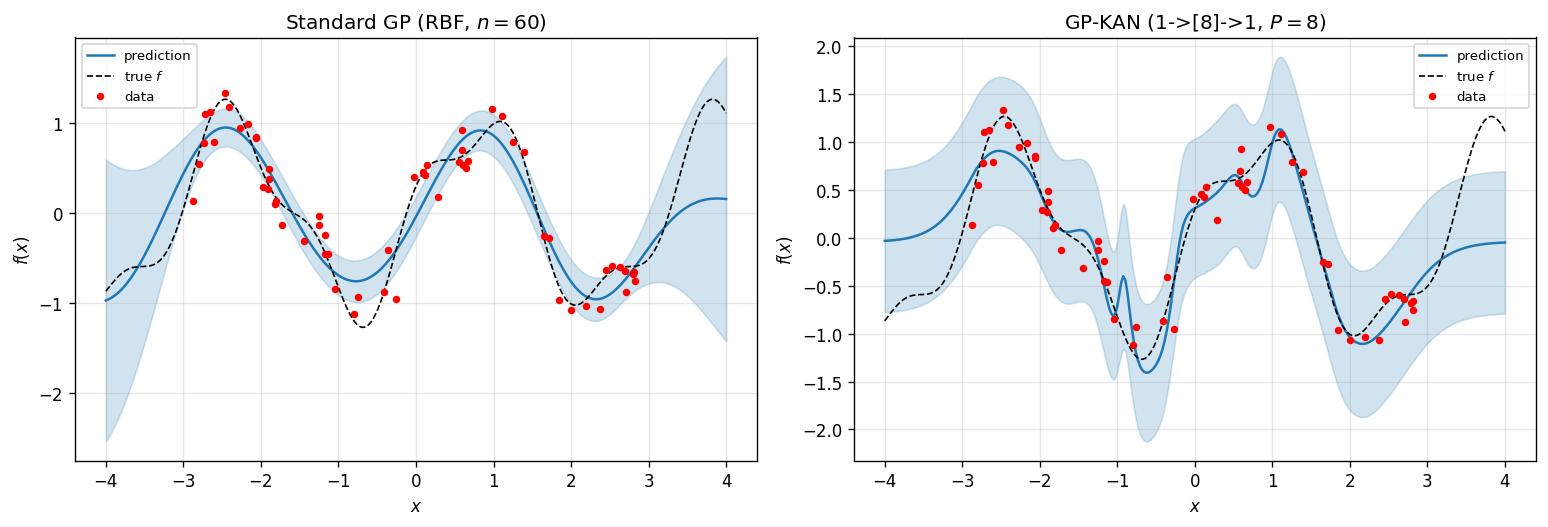

In [9]:
from src.core.models.multivar_gp.dense_gp import DenseGP

cfg_gp = ConfigParser()
cfg_gp["KERNEL"] = {"type": "RBF", "lmbda": str(noise_std**2), "alpha": "1.0"}
cfg_gp["SPARSE"] = {
    "use_sparse": "false",
    "num_inducing": "20",
    "inducing_method": "kmeans",
}

gp = DenseGP(cfg_gp, np.array([1.0]))
gp.fit(X_train, y_train)
mu_gp, std_gp = gp.predict(X_test, return_std=True)
mu_gp, std_gp = np.asarray(mu_gp), np.asarray(std_gp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, mu, std, title in [
    (axes[0], mu_gp, std_gp, f"Standard GP (RBF, $n={len(X_train)}$)"),
    (axes[1], mu_t, std_t, "GP-KAN (1->[8]->1, $P=8$)"),
]:
    ax.fill_between(X_test.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="C0")
    ax.plot(X_test, mu, "C0", lw=1.5, label="prediction")
    ax.plot(X_test, f_true(X_test.ravel()), "k--", lw=1, label="true $f$")
    ax.scatter(X_train, y_train, c="red", s=12, zorder=5, label="data")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Inducing point log-likelihood and pretraining

Before the main SGD loop, kernel hyperparameters $(\ell, s, \delta)$ are pretrained by maximising the log-likelihood of the inducing points under the GP prior:

$$\log p(\mathbf{h} \mid \mathbf{z}, \theta) = -\frac{1}{2} \mathbf{h}^\top K_{\theta}^{-1} \mathbf{h} - \frac{1}{2} \log |K_\theta| - \frac{P}{2} \log 2\pi$$

This is the same marginal likelihood as in standard GP hyperparameter optimisation, but applied to the inducing points only. It ensures the GP prior is compatible with the inducing point values before the network sees any data.

Below: the inducing point log-likelihood landscape for a single GP neuron, sweeping length scale and signal variance.

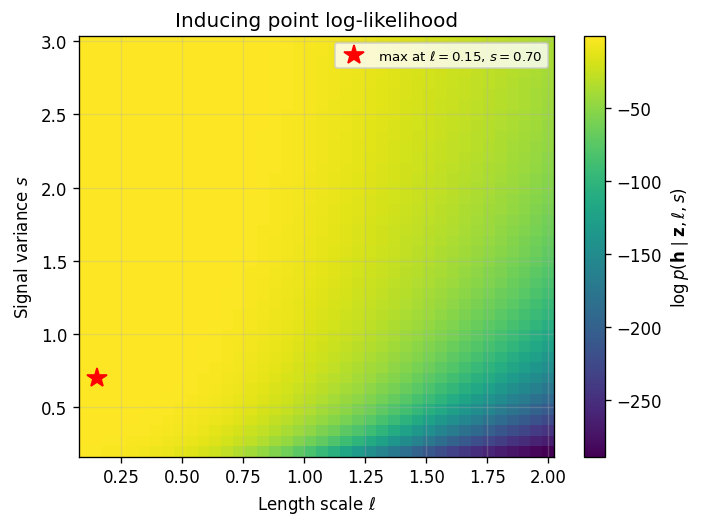

In [10]:
cfg_ll = make_kan_config(GP={"num_inducing_points": "6"})
layer_ll = DenseGPLayer(
    input_size=1, output_size=1, config=cfg_ll, key=jax.random.PRNGKey(3)
)

ls_range = np.linspace(0.1, 2.0, 40)
s_range = np.linspace(0.2, 3.0, 40)
ll_grid = np.zeros((len(s_range), len(ls_range)))

original_params = layer_ll.get_params()
for i, s_val in enumerate(s_range):
    for j, ls_val in enumerate(ls_range):
        layer_ll.length_scale = jnp.log(jnp.array([[ls_val]]))
        layer_ll.s = jnp.log(jnp.array([[s_val]]))
        try:
            ll_grid[i, j] = float(layer_ll.loglikelihood())
        except Exception:
            ll_grid[i, j] = np.nan

layer_ll.set_params(original_params)

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.pcolormesh(ls_range, s_range, ll_grid, shading="auto", cmap="viridis")
bi, bj = np.unravel_index(np.nanargmax(ll_grid), ll_grid.shape)
ax.plot(
    ls_range[bj],
    s_range[bi],
    "r*",
    ms=12,
    label=f"max at $\\ell={ls_range[bj]:.2f}$, $s={s_range[bi]:.2f}$",
)
ax.set_xlabel(r"Length scale $\ell$")
ax.set_ylabel(r"Signal variance $s$")
ax.set_title("Inducing point log-likelihood")
ax.legend(fontsize=8)
fig.colorbar(im, ax=ax, label=r"$\log p(\mathbf{h} \mid \mathbf{z}, \ell, s)$")
plt.tight_layout()
plt.show()